In [1]:
import scanpy as sc
import numpy as np
from anndata import AnnData
from scipy.stats import rankdata
from tqdm import tqdm
from functools import partial
from scipy.sparse import csr_matrix

In [2]:
adata = sc.read_h5ad("counts_combined_filtered_BA4_sALS_PN.h5ad")

In [3]:
def in_silico_perturbation(
    adata: AnnData,
    up: list[str] | None = None,
    down: list[str] | None = None,
    strengh: float = 2,
    layer: str = "perturbation",
):
    assert isinstance(adata.X, csr_matrix), "For now, this function only supports `csr_matrix` for `adata.X`"

    gene_means = adata.X.mean(0).A1  # corpus mean (instead of median)

    up_indices = adata.var_names.get_indexer(up).tolist()
    down_indices = adata.var_names.get_indexer(down).tolist()

    print("Copying the original counts...")
    X_pert = adata.X.tolil(copy=True)

    for i in tqdm(range(adata.n_obs), desc="Generating knock-up/down"):
        start, end = adata.X.indptr[i], adata.X.indptr[i + 1]

        if end == start:
            continue

        non_zero_indices = adata.X.indices[start:end]

        norm_values: np.ndarray = adata.X.data[start:end] / gene_means[non_zero_indices]
        ranks = rankdata(norm_values).astype(int)

        sorted_norms = np.pad(norm_values.copy(), (0, adata.n_vars - len(norm_values)))
        sorted_norms.sort()

        _get_norm_factor = partial(_new_norm_factor, adata, non_zero_indices, ranks, sorted_norms)
        X_pert[i, up_indices] = (gene_means[up_indices] * _get_norm_factor(up, strengh)).astype(int)
        X_pert[i, down_indices] = (gene_means[down_indices] * _get_norm_factor(down, 1 / strengh)).astype(int)

    adata.layers[layer] = X_pert.tocsr()


def _new_norm_factor(
    adata: AnnData,
    non_zero_indices: np.ndarray,
    ranks: np.ndarray,
    sorted_norms: np.ndarray,
    genes: list[str],
    power: float,
) -> np.ndarray:
    indices_genes = adata.var_names[non_zero_indices].get_indexer(genes)
    ranks_genes = np.where(indices_genes >= 0, ranks[indices_genes], len(ranks))
    new_ranks = ((ranks_genes / adata.n_vars) ** power * adata.n_vars).astype(int)
    return sorted_norms[-new_ranks]

In [4]:
up = ["DPM1", "SCYL3", "LINCADL"]
down = ["FUCA2", "GCLC", "LINC01622", "SMIM40"]

in_silico_perturbation(adata, up=up, down=down)

Copying the original counts...


Generating knock-up/down: 100%|██████████| 112014/112014 [01:33<00:00, 1193.00it/s]


## Examples


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_perturbation_effect(adata: AnnData, gene: str):
    exp1 = adata.obs_vector(gene, layer=None)
    exp2 = adata.obs_vector(gene, layer="perturbation")

    _, axes = plt.subplots(1, 2, figsize=(6, 3))
    xlim = exp1.max()

    for ax, exp, title in [(axes[0], exp1, f"Raw {gene}"), (axes[1], exp2, f"Perturbed {gene}")]:
        sns.histplot(exp.clip(0, xlim), ax=ax, discrete=True)
        ax.set_title(title)
        sns.despine(ax=ax, offset=10, trim=True)

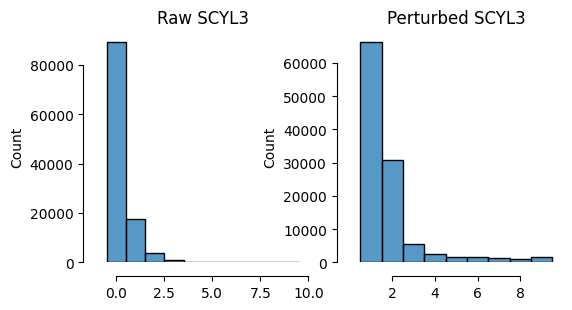

In [25]:
plot_perturbation_effect(adata, "SCYL3")

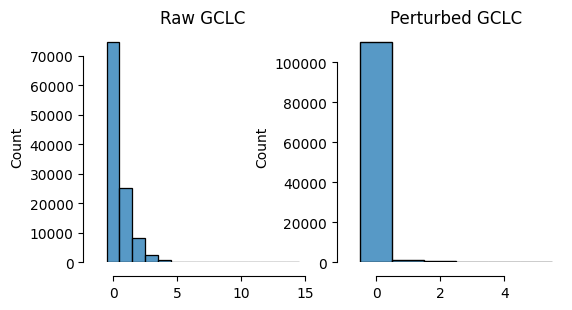

In [26]:
plot_perturbation_effect(adata, "GCLC")